In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Loding the dataset

In [ ]:

import pandas as pd


save_folder = "/content/drive/MyDrive/Computer Vision Project"

train_df = pd.read_csv(f"{save_folder}/train_processed_embedding_split.csv")
val_df = pd.read_csv(f"{save_folder}/val_processed_embedding_split.csv")
test_df = pd.read_csv(f"{save_folder}/test_processed_embedding_split.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class counts:")
print(train_df["label"].value_counts())

Train: 2171
Val: 468
Test: 450

Train class counts:
label
1. Potassium Deficiency     574
3. Magnesium Deficiency     395
2. Manganese Deficiency     304
9. Healthy sample           281
7. Rachis Blight            269
6. Fusarium Wilt            154
8. Parlatoria Blanchardi     79
4. Black Scorch              71
5. Leaf Spots                44
Name: count, dtype: int64


In [ ]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(train_df["label"])

num_classes = len(label_encoder.classes_)

print("Classes:")
print(label_encoder.classes_)
print("\nNumber of classes:", num_classes)

Classes:
['1. Potassium Deficiency' '2. Manganese Deficiency'
 '3. Magnesium Deficiency' '4. Black Scorch' '5. Leaf Spots'
 '6. Fusarium Wilt' '7. Rachis Blight' '8. Parlatoria Blanchardi'
 '9. Healthy sample']

Number of classes: 9


In [ ]:
!pip install timm pillow-heif -q

import torch
import timm
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import pillow_heif

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

pillow_heif.register_heif_opener()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 61.1 MB/s eta 0:00:00
Device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully")

Transforms created successfully


In [ ]:
class PalmDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["path"]
        label_name = self.dataframe.iloc[idx]["label"]

        label = label_encoder.transform([label_name])[0]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = PalmDataset(train_df, transform=train_transform)
val_dataset = PalmDataset(val_df, transform=val_test_transform)
test_dataset = PalmDataset(test_df, transform=val_test_transform)

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 136
Val batches: 30
Test batches: 29


In [ ]:
import os

print(train_df.head())
print(train_df.columns)

print("Example path:")
print(train_df.iloc[0]["path"])

print("Path exists?", os.path.exists(train_df.iloc[0]["path"]))

                                                path                    label  \
0  /content/drive/MyDrive/Diseases of date palm l...  1. Potassium Deficiency   
1  /content/drive/MyDrive/Diseases of date palm l...  1. Potassium Deficiency   
2  /content/drive/MyDrive/Diseases of date palm l...  1. Potassium Deficiency   
3  /content/drive/MyDrive/Diseases of date palm l...  1. Potassium Deficiency   
4  /content/drive/MyDrive/Diseases of date palm l...  1. Potassium Deficiency   

       filename                     embedding_group  
0  M9 (131).png  1. Potassium Deficiency_embgroup_0  
1  M9 (104).png  1. Potassium Deficiency_embgroup_1  
2  M9 (135).png  1. Potassium Deficiency_embgroup_2  
3  M9 (118).png  1. Potassium Deficiency_embgroup_3  
4  M9 (130).png  1. Potassium Deficiency_embgroup_4  
Index(['path', 'label', 'filename', 'embedding_group'], dtype='object')
Example path:
/content/drive/MyDrive/Diseases of date palm leaves dataset/Diseases of date palm leaves dataset/Infect

In [ ]:
model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

print("ConvNeXt-Tiny loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

ConvNeXt-Tiny loaded successfully


## 1st run without weights

In [ ]:

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

num_epochs = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)




In [ ]:
import os
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

# =========================
# SAVE FOLDER
# =========================

save_dir = "/content/drive/MyDrive/ConvNeXt-Tiny-NoClassWeights"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_convnext_tiny.pth")

print("Model will be saved to:")
print(best_model_path)


# =========================
# TRAINING LOOP
# =========================

best_val_f1 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_loss = 0.0
    train_preds = []
    train_true = []

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    train_f1 = f1_score(train_true, train_preds, average="macro")

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    # -------------------------
    # STORE HISTORY
    # -------------------------
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    # -------------------------
    # PRINT RESULTS
    # -------------------------
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_f1:.4f}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "label_classes": label_encoder.classes_
        }, best_model_path)

        print(f"Best model saved! Val Macro F1: {best_val_f1:.4f}")

print("\nTraining complete.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")
print(f"Best model saved at: {best_model_path}")

Model will be saved to:
/content/drive/MyDrive/ConvNeXt-Tiny-NoClassWeights/best_convnext_tiny.pth

Epoch [1/20]


Training:  18%|█▊        | 25/136 [02:44<12:31,  6.77s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  24%|██▍       | 33/136 [03:38<11:22,  6.63s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  30%|███       | 41/136 [04:27<10:00,  6.32s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  57%|█████▋    | 77/136 [08:14<06:06,  6.22s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserW

Train Loss: 1.2687 | Train Acc: 0.6485 | Train Macro F1: 0.5762
Val Loss:   0.8422 | Val Acc:   0.8590 | Val Macro F1:   0.7519
Best model saved! Val Macro F1: 0.7519

Epoch [2/20]


Training:   7%|▋         | 9/136 [00:00<00:11, 11.02it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   8%|▊         | 11/136 [00:01<00:11, 10.66it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  20%|█▉        | 27/136 [00:02<00:08, 12.45it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes

Train Loss: 0.7049 | Train Acc: 0.9152 | Train Macro F1: 0.8558
Val Loss:   0.6813 | Val Acc:   0.9231 | Val Macro F1:   0.8479
Best model saved! Val Macro F1: 0.8479

Epoch [3/20]


...

Train Loss: 0.4860 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.5714 | Val Acc:   0.9594 | Val Macro F1:   0.9040

Epoch [19/20]


Training:  38%|███▊      | 51/136 [00:04<00:07, 11.49it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  49%|████▉     | 67/136 [00:06<00:05, 11.78it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  62%|██████▎   | 85/136 [00:07<00:04, 11.45it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  64%|██████▍   | 87/136 [00:07<00:04, 11.47it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserW

Train Loss: 0.4859 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.5707 | Val Acc:   0.9594 | Val Macro F1:   0.9040

Epoch [20/20]


Training:   1%|          | 1/136 [00:00<00:44,  3.07it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  10%|▉         | 13/136 [00:01<00:11, 10.63it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▎        | 17/136 [00:01<00:10, 11.11it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  57%|█████▋    | 77/136 [00:06<00:04, 11.85it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  58%|█████▊    | 79/136 [00:06<00:04, 11.80it/s]/usr/lo

Train Loss: 0.4859 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.5705 | Val Acc:   0.9594 | Val Macro F1:   0.9040

Training complete.
Best validation Macro F1: 0.9061
Best model saved at: /content/drive/MyDrive/ConvNeXt-Tiny-NoClassWeights/best_convnext_tiny.pth


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
from tqdm import tqdm

best_model_path='/content/drive/MyDrive/ConvNeXt-Tiny-NoClassWeights/best_convnext_tiny.pth'

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(test_true, test_preds))
print("Test Macro F1:", f1_score(test_true, test_preds, average="macro"))

print(classification_report(
    test_true,
    test_preds,
    target_names=label_encoder.classes_
))



Testing:  86%|████████▌ | 25/29 [02:43<00:25,  6.28s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing: 100%|██████████| 29/29 [02:58<00:00,  6.17s/it]

Test Accuracy: 0.9688888888888889
Test Macro F1: 0.9255590402089103
                          precision    recall  f1-score   support

 1. Potassium Deficiency       0.98      0.99      0.99       128
 2. Manganese Deficiency       1.00      1.00      1.00        59
 3. Magnesium Deficiency       0.99      0.96      0.97        95
         4. Black Scorch       1.00      0.90      0.95        21
           5. Leaf Spots       0.88      0.64      0.74        11
        6. Fusarium Wilt       0.72      0.95      0.82        22
        7. Rachis Blight       1.00      1.00      1.00        59
8. Parlatoria Blanchardi       0.91      0.83      0.87        12
       9. Healthy sample       0.98      1.00      0.99        43

                accuracy                           0.97       450
               macro avg       0.94      0.92      0.93       450
            weighted avg       0.97      0.97      0.97       450



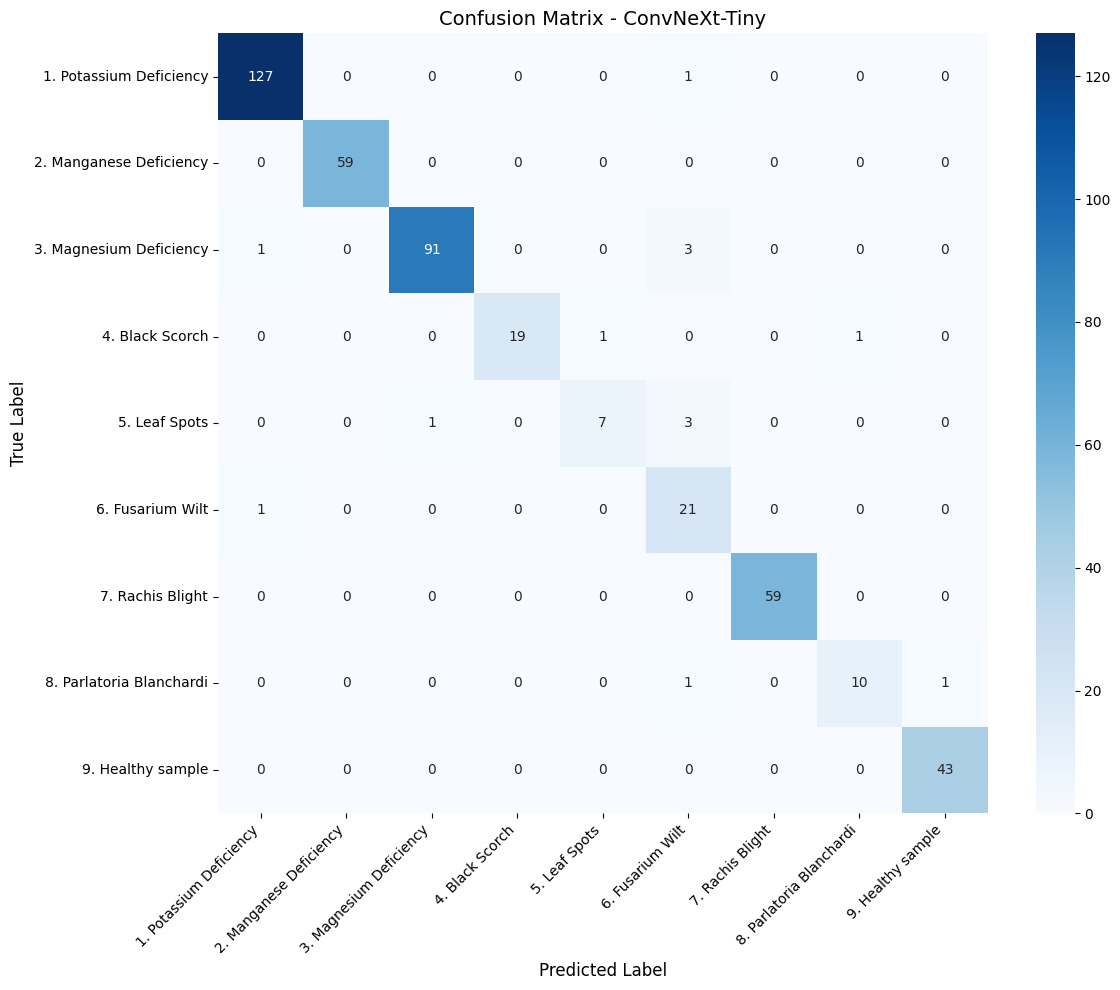

In [ ]:
# ============================================================
# FINAL CONFUSION MATRIX - CONVNEXT-TINY
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.title(
    "Confusion Matrix - ConvNeXt-Tiny",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 1st run with weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_numeric = label_encoder.transform(train_df["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_numeric
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:")
for class_name, weight in zip(label_encoder.classes_, class_weights.cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

Class weights:
1. Potassium Deficiency: 0.420
2. Manganese Deficiency: 0.793
3. Magnesium Deficiency: 0.611
4. Black Scorch: 3.397
5. Leaf Spots: 5.482
6. Fusarium Wilt: 1.566
7. Rachis Blight: 0.897
8. Parlatoria Blanchardi: 3.053
9. Healthy sample: 0.858


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

num_epochs = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

In [ ]:
import os
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

# =========================
# SAVE FOLDER
# =========================

save_dir = "/content/drive/MyDrive/ConvNeXt-Tiny"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_convnext_tiny.pth")

print("Model will be saved to:")
print(best_model_path)


# =========================
# TRAINING LOOP
# =========================

best_val_f1 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_loss = 0.0
    train_preds = []
    train_true = []

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    train_f1 = f1_score(train_true, train_preds, average="macro")

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    # -------------------------
    # STORE HISTORY
    # -------------------------
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    # -------------------------
    # PRINT RESULTS
    # -------------------------
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_f1:.4f}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "label_classes": label_encoder.classes_
        }, best_model_path)

        print(f"Best model saved! Val Macro F1: {best_val_f1:.4f}")

print("\nTraining complete.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")
print(f"Best model saved at: {best_model_path}")

Model will be saved to:
/content/drive/MyDrive/ConvNeXt-Tiny/best_convnext_tiny.pth

Epoch [1/20]


Training:  12%|█▎        | 17/136 [01:55<12:40,  6.39s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  27%|██▋       | 37/136 [03:56<09:41,  5.87s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  70%|██████▉   | 95/136 [09:52<04:49,  7.06s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  81%|████████  | 110/136 [11:18<02:11,  5.06s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  82%|████████▏ | 111/136 [11:29<02:51,  6.87s/it]/usr

Train Loss: 1.3606 | Train Acc: 0.5099 | Train Macro F1: 0.4684
Val Loss:   0.8884 | Val Acc:   0.6709 | Val Macro F1:   0.6552
Best model saved! Val Macro F1: 0.6552

Epoch [2/20]


Training:  12%|█▎        | 17/136 [00:01<00:11, 10.36it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  15%|█▌        | 21/136 [00:02<00:11,  9.98it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  23%|██▎       | 31/136 [00:03<00:10, 10.04it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  40%|████      | 55/136 [00:05<00:07, 10.61it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserW

Train Loss: 0.5481 | Train Acc: 0.7959 | Train Macro F1: 0.7666
Val Loss:   0.3975 | Val Acc:   0.8868 | Val Macro F1:   0.8527
Best model saved! Val Macro F1: 0.8527

Epoch [3/20]


...

Train Loss: 0.0010 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.2119 | Val Acc:   0.9637 | Val Macro F1:   0.9070

Epoch [19/20]


Training:   1%|          | 1/136 [00:00<00:43,  3.12it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  18%|█▊        | 25/136 [00:02<00:09, 11.15it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  39%|███▉      | 53/136 [00:04<00:07, 11.01it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  55%|█████▌    | 75/136 [00:06<00:05, 11.05it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  68%|██████▊   | 93/136 [00:08<00:03, 11.19it/s]/usr/lo

Train Loss: 0.0012 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.2130 | Val Acc:   0.9637 | Val Macro F1:   0.9070

Epoch [20/20]


Training:  12%|█▎        | 17/136 [00:01<00:11, 10.39it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  15%|█▌        | 21/136 [00:02<00:10, 10.79it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  21%|██▏       | 29/136 [00:02<00:10, 10.55it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  62%|██████▎   | 85/136 [00:08<00:04, 10.58it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  71%|███████▏  | 97/136 [00:09<00:03, 10.99it/s]/usr/l

Train Loss: 0.0007 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   0.2131 | Val Acc:   0.9637 | Val Macro F1:   0.9070

Training complete.
Best validation Macro F1: 0.9169
Best model saved at: /content/drive/MyDrive/ConvNeXt-Tiny/best_convnext_tiny.pth


### results of 1st run

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
from tqdm import tqdm

best_model_path='/content/drive/MyDrive/ConvNeXt-Tiny/best_convnext_tiny.pth'

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(test_true, test_preds))
print("Test Macro F1:", f1_score(test_true, test_preds, average="macro"))

print(classification_report(
    test_true,
    test_preds,
    target_names=label_encoder.classes_
))



Testing:  76%|███████▌  | 22/29 [00:00<00:00, 50.51it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing: 100%|██████████| 29/29 [00:00<00:00, 42.86it/s]

Test Accuracy: 0.9488888888888889
Test Macro F1: 0.8936174206599787
                          precision    recall  f1-score   support

 1. Potassium Deficiency       0.98      0.98      0.98       128
 2. Manganese Deficiency       1.00      1.00      1.00        59
 3. Magnesium Deficiency       1.00      0.89      0.94        95
         4. Black Scorch       0.76      0.76      0.76        21
           5. Leaf Spots       0.62      0.73      0.67        11
        6. Fusarium Wilt       0.76      0.86      0.81        22
        7. Rachis Blight       0.98      1.00      0.99        59
8. Parlatoria Blanchardi       0.80      1.00      0.89        12
       9. Healthy sample       1.00      1.00      1.00        43

                accuracy                           0.95       450
               macro avg       0.88      0.91      0.89       450
            weighted avg       0.95      0.95      0.95       450



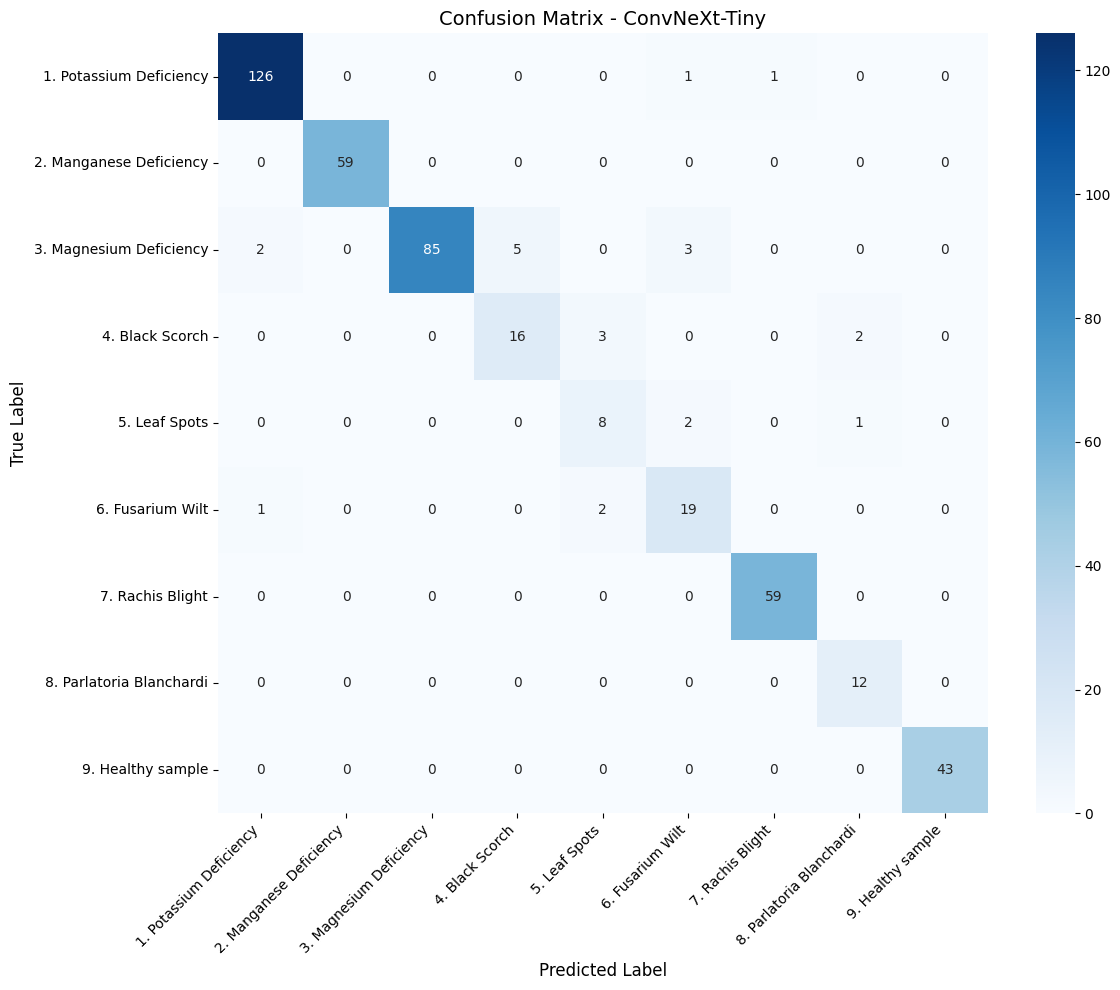

In [ ]:
# ============================================================
# FINAL CONFUSION MATRIX - CONVNEXT-TINY
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.title(
    "Confusion Matrix - ConvNeXt-Tiny",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 2nd run with weights

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.05
)

num_epochs = 20


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

In [ ]:
import os
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

# =========================
# SAVE FOLDER
# =========================

save_dir = "/content/drive/MyDrive/ConvNeXt-Tiny2"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_convnext_tiny.pth")

print("Model will be saved to:")
print(best_model_path)


# =========================
# TRAINING LOOP
# =========================

best_val_f1 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_loss = 0.0
    train_preds = []
    train_true = []

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    train_f1 = f1_score(train_true, train_preds, average="macro")

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    # -------------------------
    # STORE HISTORY
    # -------------------------
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    # -------------------------
    # PRINT RESULTS
    # -------------------------
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_f1:.4f}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "label_classes": label_encoder.classes_
        }, best_model_path)

        print(f"Best model saved! Val Macro F1: {best_val_f1:.4f}")

print("\nTraining complete.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")
print(f"Best model saved at: {best_model_path}")

Model will be saved to:
/content/drive/MyDrive/ConvNeXt-Tiny2/best_convnext_tiny.pth

Epoch [1/20]


Training:   3%|▎         | 4/136 [00:16<06:44,  3.06s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  18%|█▊        | 25/136 [01:29<06:12,  3.35s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  35%|███▍      | 47/136 [02:42<04:53,  3.30s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  70%|██████▉   | 95/136 [05:19<02:11,  3.20s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWa

Train Loss: 1.5979 | Train Acc: 0.5827 | Train Macro F1: 0.5570
Val Loss:   1.5786 | Val Acc:   0.7970 | Val Macro F1:   0.7795
Best model saved! Val Macro F1: 0.7795

Epoch [2/20]


Training:   1%|          | 1/136 [00:00<00:19,  7.07it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 16/136 [00:00<00:04, 25.38it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  18%|█▊        | 25/136 [00:01<00:04, 26.24it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  32%|███▏      | 43/136 [00:01<00:03, 26.61it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWa

Train Loss: 1.0397 | Train Acc: 0.8922 | Train Macro F1: 0.8707
Val Loss:   1.4159 | Val Acc:   0.8440 | Val Macro F1:   0.8231
Best model saved! Val Macro F1: 0.8231

Epoch [3/20]


...

Train Loss: 0.7983 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   1.1212 | Val Acc:   0.9765 | Val Macro F1:   0.9357

Epoch [19/20]


Training:   0%|          | 0/136 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   3%|▎         | 4/136 [00:00<00:07, 18.28it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  25%|██▌       | 34/136 [00:01<00:03, 27.89it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  34%|███▍      | 46/136 [00:01<00:03, 28.10it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  38%|███▊      | 52/136 [00:01<00:02, 28.16it/s]/usr/local/lib/p

Train Loss: 0.8035 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   1.1220 | Val Acc:   0.9744 | Val Macro F1:   0.9334

Epoch [20/20]


Training:   1%|          | 1/136 [00:00<00:18,  7.32it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   5%|▌         | 7/136 [00:00<00:05, 22.41it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  38%|███▊      | 52/136 [00:01<00:02, 28.09it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  56%|█████▌    | 76/136 [00:02<00:02, 28.10it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  74%|███████▎  | 100/136 [00:03<00:01, 28.05it/s]/usr/lo

Train Loss: 0.7996 | Train Acc: 1.0000 | Train Macro F1: 1.0000
Val Loss:   1.1220 | Val Acc:   0.9744 | Val Macro F1:   0.9334

Training complete.
Best validation Macro F1: 0.9538
Best model saved at: /content/drive/MyDrive/ConvNeXt-Tiny2/best_convnext_tiny.pth


### results of 2nd run

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
from tqdm import tqdm

best_model_path='/content/drive/MyDrive/ConvNeXt-Tiny2/best_convnext_tiny.pth'

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(test_true, test_preds))
print("Test Macro F1:", f1_score(test_true, test_preds, average="macro"))

print(classification_report(
    test_true,
    test_preds,
    target_names=label_encoder.classes_
))



Testing:  79%|███████▉  | 23/29 [00:01<00:00, 16.79it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing:  86%|████████▌ | 25/29 [00:01<00:00, 16.14it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing: 100%|██████████| 29/29 [00:01<00:00, 15.72it/s]

Test Accuracy: 0.9711111111111111
Test Macro F1: 0.952201331889535
                          precision    recall  f1-score   support

 1. Potassium Deficiency       0.99      0.98      0.99       128
 2. Manganese Deficiency       1.00      1.00      1.00        59
 3. Magnesium Deficiency       0.99      0.92      0.95        95
         4. Black Scorch       0.95      0.95      0.95        21
           5. Leaf Spots       0.73      1.00      0.85        11
        6. Fusarium Wilt       0.87      0.91      0.89        22
        7. Rachis Blight       0.97      1.00      0.98        59
8. Parlatoria Blanchardi       0.92      1.00      0.96        12
       9. Healthy sample       1.00      1.00      1.00        43

                accuracy                           0.97       450
               macro avg       0.94      0.97      0.95       450
            weighted avg       0.97      0.97      0.97       450



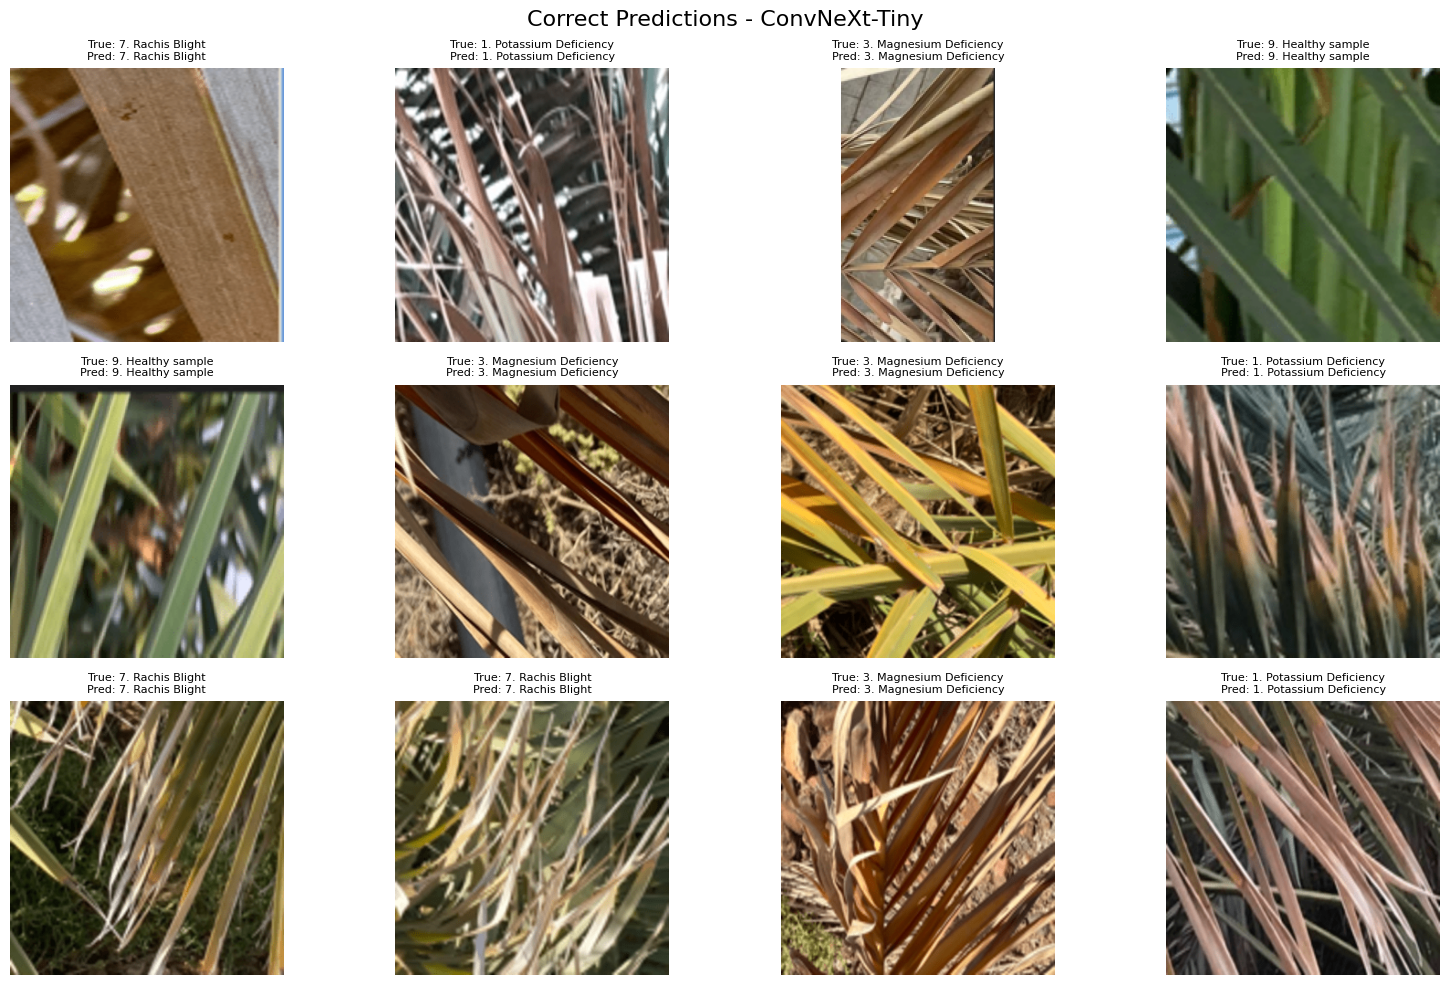

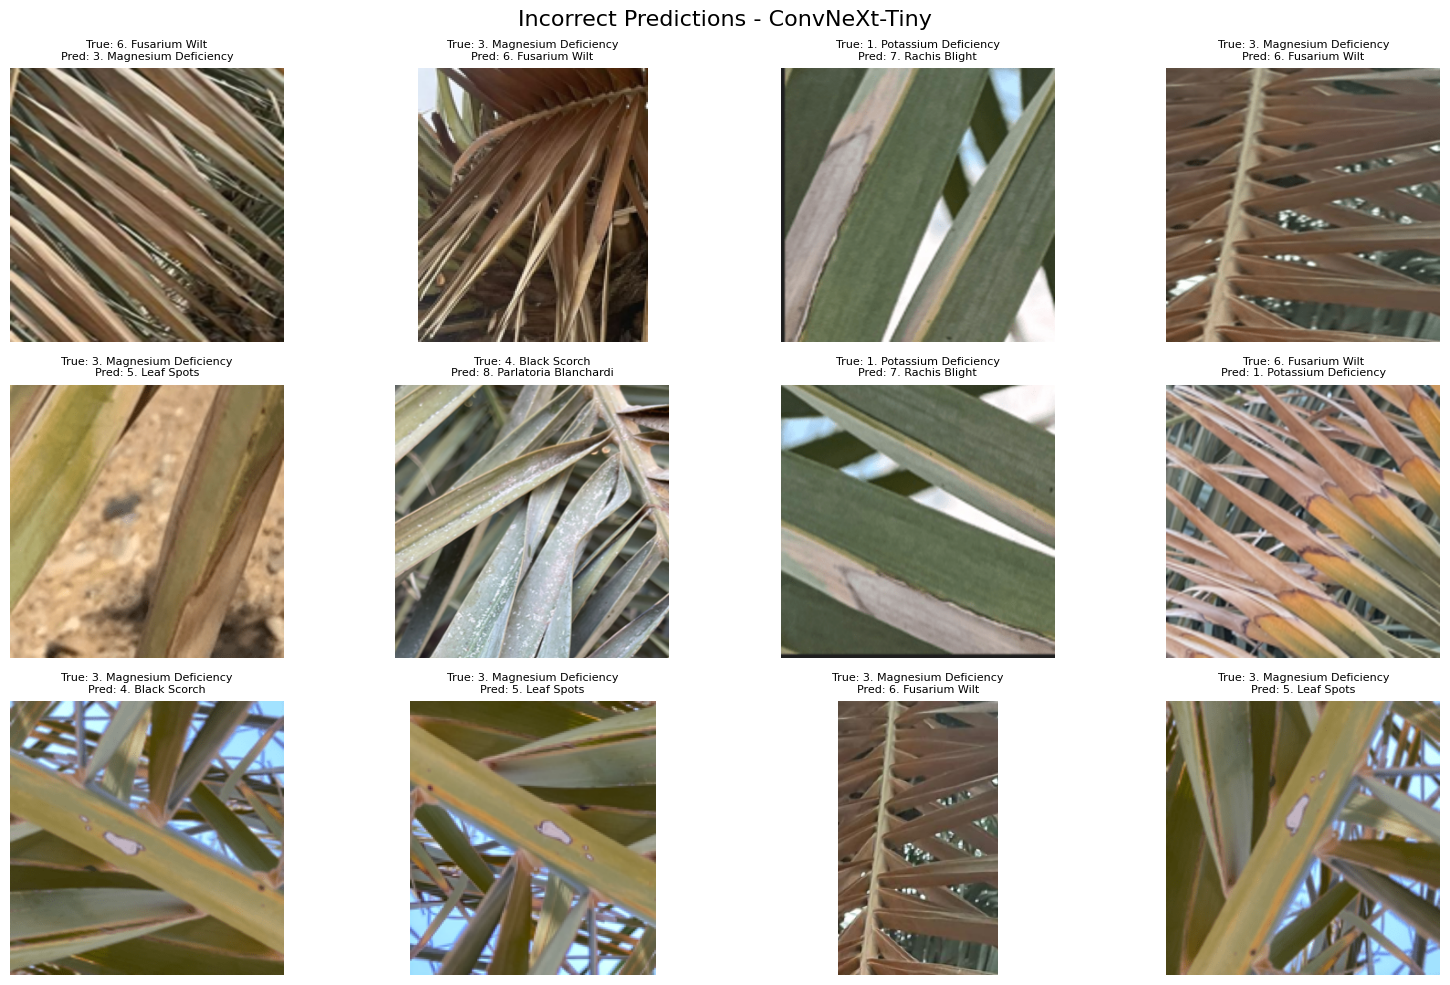

In [ ]:
# FINAL PREDICTIONS VISUALIZATION
# ConvNeXt-Tiny
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

# Create results dataframe
test_results = test_df.copy()

test_results["true_label"] = label_encoder.inverse_transform(test_true)

test_results["predicted_label"] = label_encoder.inverse_transform(test_preds)

test_results["correct"] = (
    test_results["true_label"]
    ==
    test_results["predicted_label"]
)



def show_predictions(df, title, n=12):

    samples = df.sample(
        min(n, len(df)),
        random_state=42
    )

    plt.figure(figsize=(16, 10))

    for i, (_, row) in enumerate(samples.iterrows()):

        img = Image.open(row["path"]).convert("RGB")

        plt.subplot(3, 4, i + 1)

        plt.imshow(img)

        plt.axis("off")

        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}",
            fontsize=8
        )

    plt.suptitle(title, fontsize=16)

    plt.tight_layout()

    plt.show()



show_predictions(
    test_results[test_results["correct"] == True],
    "Correct Predictions - ConvNeXt-Tiny",
    n=12
)


show_predictions(
    test_results[test_results["correct"] == False],
    "Incorrect Predictions - ConvNeXt-Tiny",
    n=12
)

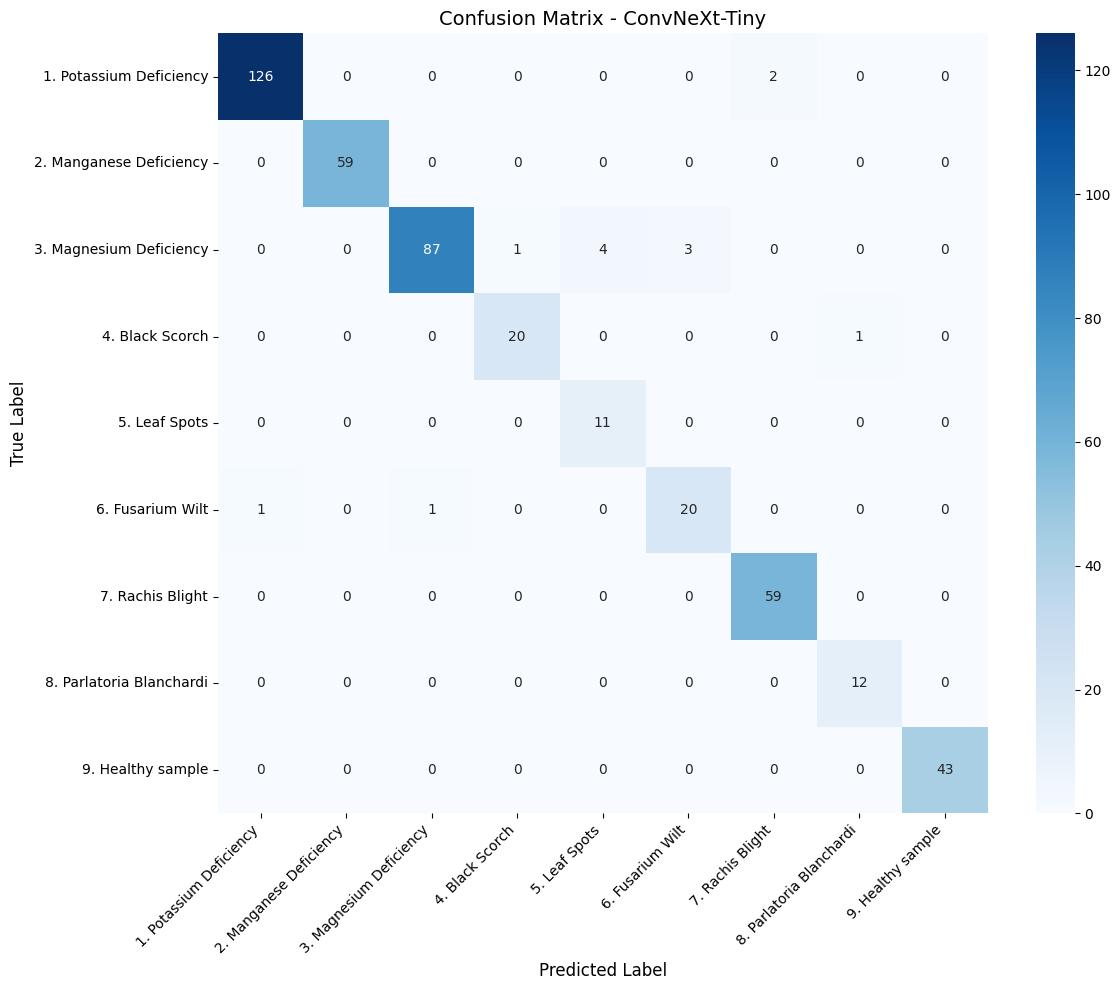

In [ ]:
# ============================================================
# FINAL CONFUSION MATRIX - CONVNEXT-TINY
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.title(
    "Confusion Matrix - ConvNeXt-Tiny",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

epochs = list(range(1, len(train_losses) + 1))

history_df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_losses,
    "train_acc": train_accuracies,
    "val_loss": val_losses,
    "val_acc": val_accuracies,
    "train_macro_f1": train_f1_scores,
    "val_macro_f1": val_f1_scores
})

display(history_df)

history_df.to_csv(
    "/content/drive/MyDrive/ConvNeXt-Tiny2/convnext_tiny_training_history.csv",
    index=False
)

,epoch,train_loss,train_acc,val_loss,val_acc,train_macro_f1,val_macro_f1
0,1,1.597918,0.582681,1.578584,0.797009,0.556961,0.779488
1,2,1.039740,0.892216,1.415898,0.844017,0.870663,0.823088
2,3,0.947771,0.947950,1.259302,0.957265,0.918384,0.907023
3,4,0.866574,0.985721,1.224077,0.931624,0.981022,0.899852
4,5,0.854691,0.984800,1.239646,0.942308,0.977404,0.916478
5,6,0.828264,0.994933,1.172332,0.959402,0.992775,0.916596
6,7,0.823485,0.995854,1.134886,0.974359,0.994960,0.953844
7,8,0.807981,0.998158,1.131666,0.976496,0.998047,0.947456
8,9,0.817054,0.999539,1.127268,0.976496,0.999500,0.945372
9,10,0.806229,1.000000,1.125281,0.974359,1.000000,0.944432


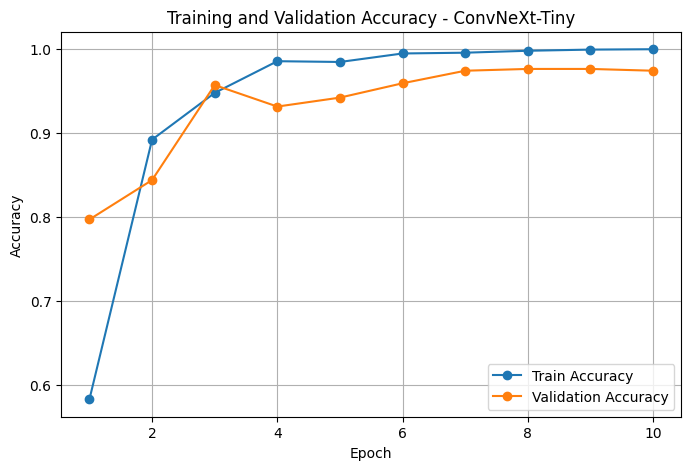

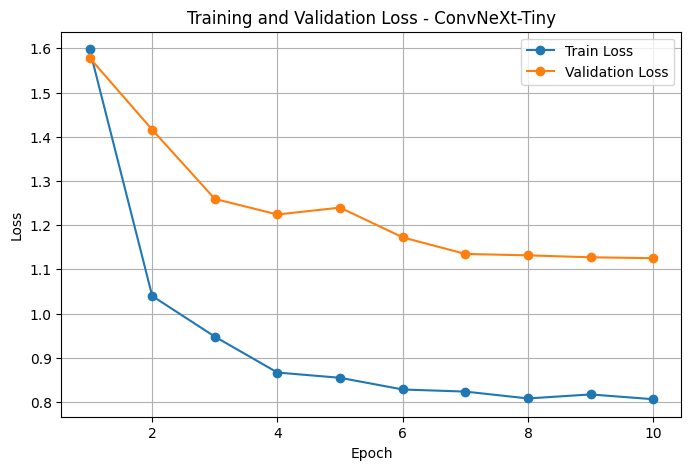

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv(
    "/content/drive/MyDrive/ConvNeXt-Tiny2/convnext_tiny_training_history.csv"
)

# Keep only first 10 epochs
df_10 = df.iloc[:10]

# Accuracy Plot
plt.figure(figsize=(8, 5))

plt.plot(
    df_10["epoch"],
    df_10["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    df_10["epoch"],
    df_10["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy - ConvNeXt-Tiny")

plt.legend()
plt.grid(True)

plt.show()


# Loss Plot
plt.figure(figsize=(8, 5))

plt.plot(
    df_10["epoch"],
    df_10["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    df_10["epoch"],
    df_10["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss - ConvNeXt-Tiny")

plt.legend()
plt.grid(True)

plt.show()

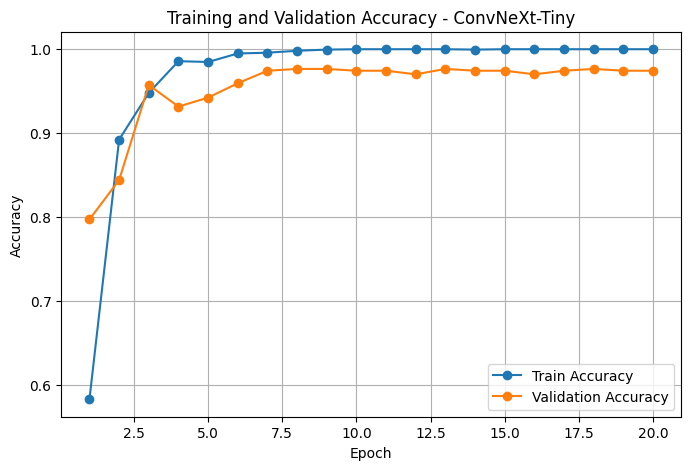

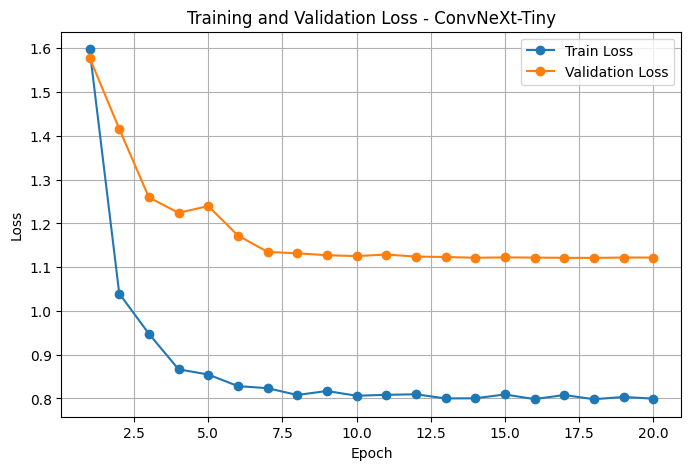

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy - ConvNeXt-Tiny")

plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss - ConvNeXt-Tiny")

plt.legend()
plt.grid(True)

plt.show()